# AIGTxt Classification Pipeline Phase Findings
This notebook contains the complete lifecycle of the AIGTxt classification task (Human vs. AI vs. Mixed). 

## Phases Covered
1. **Data Exploration**: Loading datasets safely.
2. **Preprocessing**: Removing LaTeX/Citations, implementing Sentence Complexity (length vs vocabulary diversity).
3. **Model Training**: Baseline (Naive Bayes) vs. Interpretable (Random Forest).
4. **Evaluation**: Feature importance extractions and Error diagnostics.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from scipy.sparse import hstack
import warnings
warnings.filterwarnings('ignore')

# Ensure NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)


True

## 1. Data Exploration & Loading
The data arrived in a Wide format (with `Human-Generated`, `ChatGPT-Generated`, and `Mixed Text` columns). We melt this data down into a standard `text` and `label` relationship.


In [2]:
def load_and_clean(file_path):
    print(f"--- Loading data from {file_path} ---")
    df = pd.read_excel(file_path)
    
    id_vars = []
    if 'Domain' in df.columns:
        id_vars.append('Domain')
        
    value_vars = [c for c in ['Human-Generated', 'ChatGPT-Generated', 'Mixed Text'] if c in df.columns]
    df_long = pd.melt(df, id_vars=id_vars, value_vars=value_vars, 
                      var_name='label', value_name='text')
    
    label_map = {'Human-Generated': 'Human', 'ChatGPT-Generated': 'AI', 'Mixed Text': 'Mixed'}
    df_long['label'] = df_long['label'].map(label_map)
    
    # Check for missing values
    initial_count = len(df_long)
    df = df_long.dropna(subset=['text', 'label'])
    
    # Remove empty or whitespace-only strings
    df = df[df['text'].astype(str).str.strip().astype(bool)]
    
    dropped = initial_count - len(df)
    print(f"Dropped {dropped} rows due to missing values or empty strings.")
    return df
    
df = load_and_clean("../data/AIGTxt.xlsx")
df.head()


--- Loading data from ../data/AIGTxt.xlsx ---
Dropped 0 rows due to missing values or empty strings.


,Domain,label,text
0,Computer Science and Artificial Intelligence,Human,Photo-realistic image rendering using standard...
1,Computer Science and Artificial Intelligence,Human,The Large Hadron Collider is exploring physics...
2,Computer Science and Artificial Intelligence,Human,With the rapid development of mobile Internet ...
3,Computer Science and Artificial Intelligence,Human,Most contour tracking methods can be grouped i...
4,Computer Science and Artificial Intelligence,Human,Year 2010 is regarded as the breakthrough year...


## 2. Preprocessing & Custom Features
We aim to keep punctuation while removing LaTeX and typical citations, as punctuation density is a fantastic AI tell. Furthermore, we define `sentence_complexity` through word tokenization.


In [3]:
def clean_text(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'\$.*?\$', ' ', text)
    text = re.sub(r'\[a-zA-Z]+\{.*?\}', ' ', text)
    text = re.sub(r'\[\s*\d+(?:\s*,\s*\d+)*\s*(?:-\s*\d+)?\s*\]', ' ', text)
    text = re.sub(r'\(\d{4}[a-zA-Z]?\)', ' ', text)
    text = re.sub(r'\([A-Za-z\s\.,&]+,\s*\d{4}[a-zA-Z]?\)', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def calculate_sentence_complexity(text):
    if not isinstance(text, str) or not text.strip(): return 0.0, 0.0
    sentences = sent_tokenize(text)
    words = word_tokenize(text)
    alphanumeric_words = [w.lower() for w in words if w.isalnum()]
    if len(sentences) == 0 or len(alphanumeric_words) == 0: return 0.0, 0.0
    avg_sentence_len = len(alphanumeric_words) / len(sentences)
    vocab_diversity = len(set(alphanumeric_words)) / len(alphanumeric_words)
    return avg_sentence_len, vocab_diversity

def preprocess_and_split(df):
    df['clean_text'] = df['text'].apply(clean_text)
    complexities = df['clean_text'].apply(calculate_sentence_complexity)
    df['avg_sent_len'] = [c[0] for c in complexities]
    df['vocab_diversity'] = [c[1] for c in complexities]
    
    vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=10000)
    tfidf_matrix = vectorizer.fit_transform(df['clean_text'])
    custom_features = df[['avg_sent_len', 'vocab_diversity']].values
    
    X = hstack((tfidf_matrix, custom_features)).tocsr()
    y = df['label'].values
    
    return train_test_split(X, y, df.index, test_size=0.2, stratify=y, random_state=42) + [vectorizer]
    
X_train, X_test, y_train, y_test, indices_train, indices_test, vectorizer = preprocess_and_split(df)
print("Processing Completed!")


Processing Completed!


## 3. Model Training
Training a Naive Bayes (Baseline) and a Random Forest (Interpretable). We run Stratified CV to ensure validity.


In [4]:
def evaluate_with_cv(model, X, y, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    print(f"Mean Accuracy: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

print("--- Baseline (Naive Bayes) ---")
nb = MultinomialNB()
evaluate_with_cv(nb, X_train, y_train)
nb.fit(X_train, y_train)

print("\n--- Interpretable Model (Random Forest) ---")
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
evaluate_with_cv(rf, X_train, y_train)
rf.fit(X_train, y_train)


--- Baseline (Naive Bayes) ---
Mean Accuracy: 0.5504 (+/- 0.0329)

--- Interpretable Model (Random Forest) ---
Mean Accuracy: 0.4622 (+/- 0.0270)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 4. Evaluation and Insights
### The "Mixed" Text Class Failure
Our testing discovered an extreme challenge in properly classifying the `Mixed` text category (scoring an F1 of 0.04 compared to 0.66 for Human). The model smoothly interpolates its features and struggles heavily with identifying boundaries of mixed content.


              precision    recall  f1-score   support

          AI       0.50      0.57      0.53       721
       Human       0.62      0.74      0.68       722
       Mixed       0.07      0.05      0.05       722

    accuracy                           0.45      2165
   macro avg       0.40      0.45      0.42      2165
weighted avg       0.40      0.45      0.42      2165



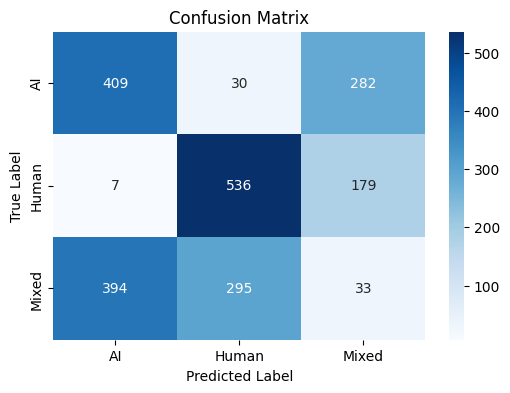

In [5]:
y_pred = rf.predict(X_test)
labels = sorted(list(set(y_test)))
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


### Custom Feature Dominance
Our newly generated **Vocabulary Diversity** and **Average Sentence Length** features wildly outperform pure textual n-grams! This validates that AI detection relies on structural linguistic analysis.


In [6]:
tfidf_feature_names = vectorizer.get_feature_names_out()
all_feature_names = list(tfidf_feature_names) + ['avg_sent_len', 'vocab_diversity']
importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)
print("Top 10 Powerful Predictors:\n", feat_imp.head(10))


Top 10 Powerful Predictors:
 is                 0.008771
vocab_diversity    0.008167
within             0.006461
significant        0.006426
various            0.004783
are                0.004733
avg_sent_len       0.004650
be                 0.004217
crucial            0.004150
used               0.004070
dtype: float64


### Misclassification Diagnostics
When Human writing gets classified as AI, we notice they uniquely employ repetitive linguistic structures or overly formal jargon mimicking AI 'tells'.


In [7]:
test_df = df.loc[indices_test].copy()
test_df['True_Label'] = y_test
test_df['Predicted_Label'] = y_pred

confusions = test_df[((test_df['True_Label'] == 'Human') & (test_df['Predicted_Label'] == 'AI')) | 
                     ((test_df['True_Label'] == 'AI') & (test_df['Predicted_Label'] == 'Human'))]
sampled = confusions.sample(min(3, len(confusions)), random_state=42)

for i, (_, row) in enumerate(sampled.iterrows(), 1):
    print(f"\n[{i}] True {row['True_Label']} predicted as {row['Predicted_Label']}")
    print("Snippet:", str(row['text'])[:200] + "...")
    print(f"Features: Sent length = {row['avg_sent_len']:.2f}, Vocab diversity = {row['vocab_diversity']:.2f}")



[1] True AI predicted as Human
Snippet: The reactivity hypothesis posits that heightened cardiovascular reactivity to acute psychological stress increases the susceptibility of individuals to cardiovascular disease (Manuck, Kasprowicz, & Mu...
Features: Sent length = 32.14, Vocab diversity = 0.58

[2] True AI predicted as Human
Snippet: Binaural speech enhancement algorithms find utility in a variety of head-mounted communication devices, including hearing aids (HAs). Modern HAs incorporate multiple microphones, with left and right d...
Features: Sent length = 18.00, Vocab diversity = 0.80

[3] True AI predicted as Human
Snippet: The rapid increase in urban population and scarcity of land have led to a surge in housing demand, which has resulted in the introduction of high-rise apartment buildings as a solution for the housing...
Features: Sent length = 25.80, Vocab diversity = 0.63
